In [ ]:
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import transforms
import torchvision
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
train_dataset = torchvision.datasets.MNIST(root="./data",train=True,download=True,transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data",train=False,download=True,transform=transform)

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)

In [ ]:
for imag,labels in train_loader:
  break

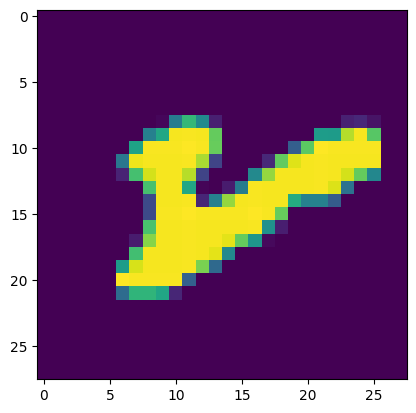

In [ ]:
imag.shape
import matplotlib.pyplot as plt
plt.imshow(imag[0].permute(2,1,0))

## Building Variational AutoEncoders

In [ ]:
x = imag  # and test batch image
print(x.shape)

torch.Size([32, 1, 28, 28])


In [ ]:
class VAE(nn.Module):
  def __init__(self,in_channels,latent_dim,device):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Conv2d(in_channels,12,3,1),
        nn.ReLU(),
        nn.Conv2d(12,24,3,1),
        nn.ReLU(),
        nn.Flatten()
    )
    self.fc_mu = nn.Linear(24*24*24,latent_dim)
    self.fc_logvar = nn.Linear(24*24*24,latent_dim)
    self.decoder_input = nn.Linear(latent_dim,24*24*24)
    self.decoder = nn.Sequential(
        nn.Unflatten(1,(24,24,24)),
        nn.ConvTranspose2d(24,12,3,1),
        nn.ConvTranspose2d(12,1,3,1),
        nn.Sigmoid()
    )

  def reprameterize(self,mu,logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.rand_like(std).to(device)
    return mu + std*eps

  def forward(self,x):
    h = self.encoder(x)
    mu , logvar = self.fc_mu(h) , self.fc_logvar(h)
    z = self.reprameterize(mu,logvar)
    return self.decoder(self.decoder_input(z)) , mu ,logvar

In [ ]:
vae = VAE(latent_dim=5,in_channels=1)
vae

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=13824, out_features=5, bias=True)
  (fc_logvar): Linear(in_features=13824, out_features=5, bias=True)
  (decoder_input): Linear(in_features=5, out_features=13824, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(24, 24, 24))
    (1): ConvTranspose2d(24, 12, kernel_size=(3, 3), stride=(1, 1))
    (2): ConvTranspose2d(12, 1, kernel_size=(3, 3), stride=(1, 1))
    (3): Sigmoid()
  )
)

In [ ]:
z_ , mu , var = vae(x)

In [ ]:
z_.shape , mu.shape , var.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32, 5]), torch.Size([32, 5]))

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
latent_dim = 5
# 1. Convert tensors to numpy
# .detach() removes from graph, .cpu() moves to RAM, .numpy() converts
mu_np = mu.detach().cpu().numpy()
# Usually 'var' in VAE code is actually 'logvar', so we convert to std dev for size
std_np = torch.exp(0.5 * var).detach().cpu().numpy()
labels_np = labels.detach().cpu().numpy() # The actual digit (0-9)

# 2. Prepare the data for Plotly
df = pd.DataFrame({
    'Latent_X': mu_np[:, 0],
    'Latent_Y': mu_np[:, 1],
    'Latent_Z': mu_np[:, 2],
    'Digit': labels_np.astype(str), # Use string for discrete colors
    'Uncertainty': std_np.mean(axis=1) # Average std dev across dimensions
})

# 3. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df,
    x='Latent_X',
    y='Latent_Y',
    z='Latent_Z',
    color='Digit',
    size='Uncertainty', # Points are larger where the model is less certain
    size_max=15,
    opacity=0.8,
    title=f"VAE Latent Space (Latent Dim = {latent_dim})",
    labels={'Digit': 'MNIST Digit'},
    template='plotly_dark' # Looks great in Colab/Notebooks
)

# 4. Show the plot
fig.show()

In [ ]:
def vae_loss_function(recon_x,x,mu,logvar):
  # 1 constructions (log likelyhood)
  BCE = F.binary_cross_entropy(recon_x, x, reduction="mean") # reduction = "sum" for proper scaling
  ## MSE used because the images are already normalized at the time of loading
  # 2 KL divergence
  KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
  return BCE + KLD

In [ ]:
vae_loss_function(z_,x,mu,var)

NameError: name 'z_' is not defined

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(in_channels=1,latent_dim=3,device=device)
model.to(device)

VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=13824, out_features=3, bias=True)
  (fc_logvar): Linear(in_features=13824, out_features=3, bias=True)
  (decoder_input): Linear(in_features=3, out_features=13824, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(24, 24, 24))
    (1): ConvTranspose2d(24, 12, kernel_size=(3, 3), stride=(1, 1))
    (2): ConvTranspose2d(12, 1, kernel_size=(3, 3), stride=(1, 1))
    (3): Sigmoid()
  )
)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

In [ ]:
epochs = 20
train_loss = [] # Move this here!

for epoch in range(epochs):
    loss = 0
    for img, _ in train_loader:
        img = img.to(device)
        optimizer.zero_grad()

        recon_x, mu, log_var = model(img)
        loss_ = vae_loss_function(recon_x, img, mu, log_var)

        loss_.backward()
        optimizer.step()
        loss += loss_.item()

    avg_loss = loss / len(train_loader)
    train_loss.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/20], Loss: 0.3400
Epoch [2/20], Loss: 0.2694
Epoch [3/20], Loss: 0.2659
Epoch [4/20], Loss: 0.2647
Epoch [5/20], Loss: 0.2642
Epoch [6/20], Loss: 0.2638
Epoch [7/20], Loss: 0.2636
Epoch [8/20], Loss: 0.2635
Epoch [9/20], Loss: 0.2634
Epoch [10/20], Loss: 0.2633
Epoch [11/20], Loss: 0.2633
Epoch [12/20], Loss: 0.2633
Epoch [13/20], Loss: 0.2632
Epoch [14/20], Loss: 0.2632
Epoch [15/20], Loss: 0.2632
Epoch [16/20], Loss: 0.2632
Epoch [17/20], Loss: 0.2631
Epoch [18/20], Loss: 0.2631
Epoch [19/20], Loss: 0.2631
Epoch [20/20], Loss: 0.2631


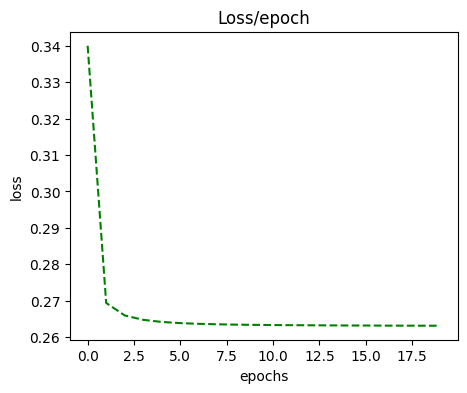

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(5,4))
plt.plot(range(epochs),train_loss,"g--",label=f"Train loss")
plt.title("Loss/epoch")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
latent_dim = 3
# 1. Convert tensors to numpy
# .detach() removes from graph, .cpu() moves to RAM, .numpy() converts
mu_np = mu.detach().cpu().numpy()
# Usually 'var' in VAE code is actually 'logvar', so we convert to std dev for size
std_np = torch.exp(0.5 * log_var).detach().cpu().numpy()
labels_np = labels.detach().cpu().numpy() # The actual digit (0-9)

# 2. Prepare the data for Plotly
df = pd.DataFrame({
    'Latent_X': mu_np[:, 0],
    'Latent_Y': mu_np[:, 1],
    'Latent_Z': mu_np[:, 2],
    'Digit': labels_np.astype(str), # Use string for discrete colors
    'Uncertainty': std_np.mean(axis=1) # Average std dev across dimensions
})

# 3. Create the 3D Scatter Plot
fig = px.scatter_3d(
    df,
    x='Latent_X',
    y='Latent_Y',
    z='Latent_Z',
    color='Digit',
    size='Uncertainty', # Points are larger where the model is less certain
    size_max=15,
    opacity=0.8,
    title=f"VAE Latent Space (Latent Dim = {latent_dim})",
    labels={'Digit': 'MNIST Digit'},
    template='plotly_dark' # Looks great in Colab/Notebooks
)

# 4. Show the plot
fig.show()

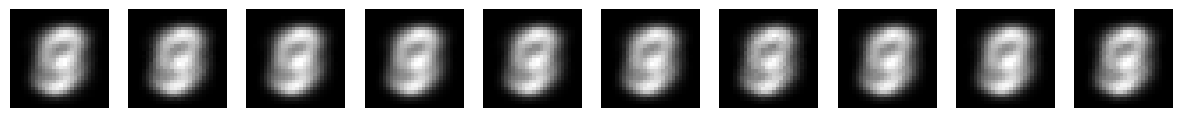

In [ ]:
import matplotlib.pyplot as plt

# 1. Set the model to evaluation mode
model.eval()

# 2. Sample random noise from a standard normal distribution N(0, 1)
# We need (number_of_samples, latent_dim)
num_samples = 10
random_latent_vectors = torch.rand(num_samples, 3).to(device) # 3 because your latent_dim = 3

# 3. Pass through the decoder only
with torch.no_grad():
    # We must project the latent vector back to the shape the decoder expects
    # In your code, this is 24 * 24 * 24
    z_projected = model.decoder_input(random_latent_vectors)

    # Decode the projected vector into images
    generated_images = model.decoder(z_projected)

# 4. Plot the results
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(1, num_samples, i+1)
    # Move to CPU and remove channel dim for grayscale plotting
    img = generated_images[i].cpu().squeeze().numpy()
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

In [ ]:
model.eval()
model.decoder(model.decoder_input(random_latent_vectors)).shape

torch.Size([10, 1, 28, 28])